## Example of Opening an Icechunk Store In-Cloud

#### *Author: Dean Henze, PO.DAAC*

This notebook demonstrates opening a virtual dataset (VDS) stored as an Icechunk store (note this technology is currently experimental, although it is gaining momentum). For a general overview of VDS's see the [Using Virutal Datasets chapter](https://podaac.github.io/tutorials/quarto_text/UsingVirtualDatasets.html) on the PO.DAAC Cookbook.

The example dataset(s) used here are from the SASSIE ECCO project (the [User Guide](https://doi.org/10.5067/SEL1D-DUG11) has a project overview). The ECCO model (Estimating the Circulation and Climate of the Ocean) was run over the arctic region over a seven year period in support of the SASSIE field experiment (Salinity and Stratification at the Sea Ice Edge). The SASSIE ECCO data are traditionally archived and available in netCDF format - one file per day(month) for the daily-mean(monthly-snapshot) datasets. The model output variables (totalling ~50 TBs) are large enough that they are spread out over 18 different netCDF datasets for the daily-means, and over 3 different datasets for the monthly-snapshots. One novel functionality of VDS's being tested here is the ability to combine the data across e.g. the 18 daily-mean datasets so users can interact with the data as if all variables were contained in a single dataset. Computing performance is TBD.

The AWS S3 paths to the SASSIE ECCO icechunk stores are

**Daily averages:**

s3://podaac-ops-cumulus-public/virtual_collections/SASSIE_ECCO_V1R1/SASSIE_ECCO_L4_DAILY_V1R1_virtual_s3.icechunk/

**Monthly snapshots:**

s3://podaac-ops-cumulus-public/virtual_collections/SASSIE_ECCO_V1R1/SASSIE_ECCO_L4_SNAPSHOT_V1R1_virtual_s3.icechunk/

## Requirements and Python environment

* Earthdata login account: An Earthdata Login account is required to access data from the NASA Earthdata system. Please visit https://urs.earthdata.nasa.gov to register and manage your Earthdata Login account.

* Compute environment: This notebook is meant to be run in the cloud (AWS instance running in us-west-2).

* The minimal working installation for Python 3.13 environment is

```
earthaccess==0.16.0
icechunk==1.1.19
xarray==2025.6.1
zarr==3.1.1
matplotlib
jupyterlab
```

***Note that the icechunk=1.1.19 dependency is important! Do not use a more recent version.***

In [1]:
import icechunk
import xarray as xr
import earthaccess

### 1. Define a function to access the icechunk store

This function does not need any modification. It defines some access keywords and a mapper to the VDS. The mapper will contain all the required access credentials and can be passed directly to xarray. In the future this step will likely be built into to earthaccess but for now we must define it in the notebook. The only inputs to the function are:

1. Your EDS credentials
2. The link to the VDS reference file (in the header of this notebook and in the next section).

In [8]:
def open_readonly_icechunkstore_s3(
                           s3path_store, creds_store, creds_data_chunks, 
                           bucket_data_chunks = "s3://podaac-ops-cumulus-protected/"):
    """
    Opens and returns an icechunk store with read-only capabilities.

    Inputs
    ------
    s3path_store: str or path
        AWS S3 path to the icechunk store, e.g. "s3://podaac-ops-cumulus-public/virtual_collections/...".
    creds_store: dict
        Credentials to access the icechunk store (e.g. EDL creds for NASA Earthdata). Expected
        dictionary keys are "accessKeyId", "secretAccessKey", and "sessionToken".
    creds_data_chunks: dict
        Credentials to access the science data that the icechunk store points to (e.g. EDL creds 
        for NASA Earthdata). Expected dictionary keys are "accessKeyId", "secretAccessKey",
        and "sessionToken".
    bucket_data_chunks: str
        Name of bucket containing the science data that the icechunk store points to. E.g. for
        PO.DAAC data this might be "s3://podaac-ops-cumulus-protected/". Note you need
        the "s3://" prefix.
    """
    
    
    # 1. Create the raw static credentials object for virtual chunks
    virtualchunk_static_creds = icechunk.s3_static_credentials(
        access_key_id = creds_data_chunks["accessKeyId"],
        secret_access_key = creds_data_chunks["secretAccessKey"],
        session_token = creds_data_chunks["sessionToken"]
    )
    auth_map = icechunk.containers_credentials({
        bucket_data_chunks: virtualchunk_static_creds
    })
    
    # 2. Config for the store / metadata repository
    s3path_split = s3path_store.split("/")
    bucket_store = "/".join(s3path_split[2:3])
    prefix_store = "/".join(s3path_split[3:])

    storage = icechunk.s3_storage(
        bucket = bucket_store,
        prefix = prefix_store,
        access_key_id = creds_store['accessKeyId'],
        secret_access_key = creds_store['secretAccessKey'],
        session_token = creds_store['sessionToken']
    )
    
    # 3. Open the repository, passing the compiled auth_map!
    repo = icechunk.Repository.open(
        storage,
        authorize_virtual_chunk_access=auth_map
    )
    
    # 4. Return the store
    session = repo.readonly_session("main")
    return session.store

### 2. Access store and open data with Xarray

Steps are to:

1. Login to NASA EDL.
2. Use the above function to get the icechunk store mapper.
3. Pass the mapper into Xarray to open the dataset.
4. Perform some sample computations

In [3]:
# 1. Authenticate with NASA Earthdata and dynamically fetch S3 credentials  ------------------------------------------
earthaccess.login() # Uses your ~/.netrc file or environment variables if configured
ea_creds = earthaccess.get_s3_credentials(daac="PODAAC")

Enter your Earthdata Login username:  deanh808
Enter your Earthdata password:  ········


The AWS S3 paths to the SASSIE ECCO icechunk stores are

**Daily averages:**

s3://podaac-ops-cumulus-public/virtual_collections/SASSIE_ECCO_V1R1/SASSIE_ECCO_L4_DAILY_V1R1_virtual_s3.icechunk/

**Monthly snapshots:**

s3://podaac-ops-cumulus-public/virtual_collections/SASSIE_ECCO_V1R1/SASSIE_ECCO_L4_SNAPSHOT_V1R1_virtual_s3.icechunk/

In [4]:
## 2. Get the icechunk store mapper  ----------------------------------------------------------------------------------
s3path_store = "s3://podaac-ops-cumulus-public/virtual_collections/SASSIE_ECCO_V1R1/SASSIE_ECCO_L4_DAILY_V1R1_virtual_s3.icechunk/"
store = open_readonly_icechunkstore_s3(
    s3path_store, 
    ea_creds, ea_creds, 
    bucket_data_chunks = "s3://podaac-ops-cumulus-protected/"
)

In [5]:
%%time

## 3. Open dataset  ---------------------------------------------------------------------------------------------------
ds = xr.open_zarr(store, consolidated=False)
ds

/opt/coiled/env/lib/python3.14/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


CPU times: user 828 ms, sys: 163 ms, total: 991 ms
Wall time: 1.58 s


<xarray.Dataset> Size: 46TB
Dimensions:    (time: 2581, k_l: 90, j: 1080, i: 1800, i_g: 1800, j_g: 1080,
                k: 90, k_u: 90, nb: 4, k_p1: 91, nv: 2)
Coordinates: (12/23)
    XC         (j, i) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
    XC_bnds    (j, i, nb) float32 31MB dask.array<chunksize=(1080, 1800, 4), meta=np.ndarray>
    YC         (j, i) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
    XU         (j, i_g) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
    YC_bnds    (j, i, nb) float32 31MB dask.array<chunksize=(1080, 1800, 4), meta=np.ndarray>
    YU         (j, i_g) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
    ...         ...
  * j_g        (j_g) int32 4kB 0 1 2 3 4 5 6 ... 1074 1075 1076 1077 1078 1079
  * k_p1       (k_p1) int32 364B 0 1 2 3 4 5 6 7 8 ... 83 84 85 86 87 88 89 90
  * k_l        (k_l) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
    time_bnds  (time, nv) datetime64[ns] 41kB dask.array<chunksize=(1, 2), meta=np.ndarray>
  * k_u        (k_u) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
  * time       (time) datetime64[ns] 21kB 2014-01-15T12:00:00 ... 2021-02-07T...
Dimensions without coordinates: nb, nv
Data variables: (12/83)
    ADVr_SLT   (time, k_l, j, i) float32 2TB dask.array<chunksize=(1, 15, 270, 450), meta=np.ndarray>
    ADVr_TH    (time, k_l, j, i) float32 2TB dask.array<chunksize=(1, 15, 270, 450), meta=np.ndarray>
    ADVxHEFF   (time, j, i_g) float32 20GB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    ADVxAREA   (time, j, i_g) float32 20GB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    ADVyAREA   (time, j_g, i) float32 20GB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    ADVx_SLT   (time, k, j, i_g) float32 2TB dask.array<chunksize=(1, 15, 270, 450), meta=np.ndarray>
    ...         ...
    oceQsw     (time, j, i) float32 20GB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    oceTAUX    (time, j, i_g) float32 20GB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    sIceLoad   (time, j, i) float32 20GB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    oceFWflx   (time, j, i) float32 20GB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    oceTAUY    (time, j_g, i) float32 20GB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    oceQnet    (time, j, i) float32 20GB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
Attributes: (12/49)
    acknowledgement:                   This research was carried out by the J...
    author:                            Marie Zahn, Mike Wood, Ian Fenty, and ...
    cdm_data_type:                     Grid
    Conventions:                       CF-1.8, ACDD-1.3
    creator_email:                     marie.j.zahn@jpl.nasa.gov
    creator_institution:               NASA Jet Propulsion Laboratory (JPL)
    ...                                ...
    geospatial_vertical_min:           -7000.0
    geospatial_vertical_positive:      up
    geospatial_vertical_resolution:    variable
    geospatial_vertical_units:         meter
    identifier_product_doi:            https://doi.org/10.5067/SEL1D-DUG11
    date_created:                      2026-03-21T00:00:00Z

#### 4. Sample computations

#### Map of salinity at a single depth and time

CPU times: user 1.73 s, sys: 341 ms, total: 2.07 s
Wall time: 2.44 s


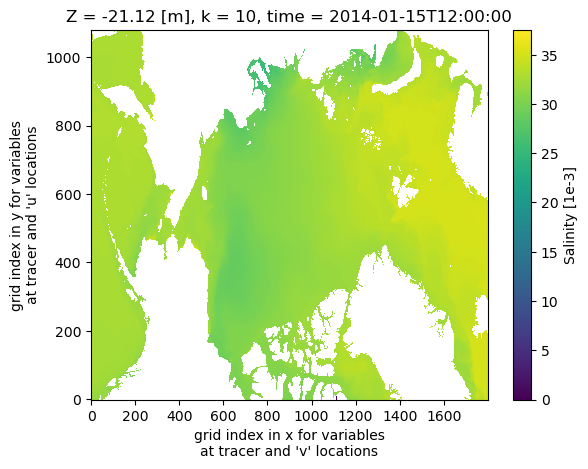

In [6]:
%%time
ds["SALT"].isel(time=0, k=10).plot()

#### Time series of salinity at a single grid point and depth, over the entire record

CPU times: user 2min 7s, sys: 21.6 s, total: 2min 29s
Wall time: 3min 27s


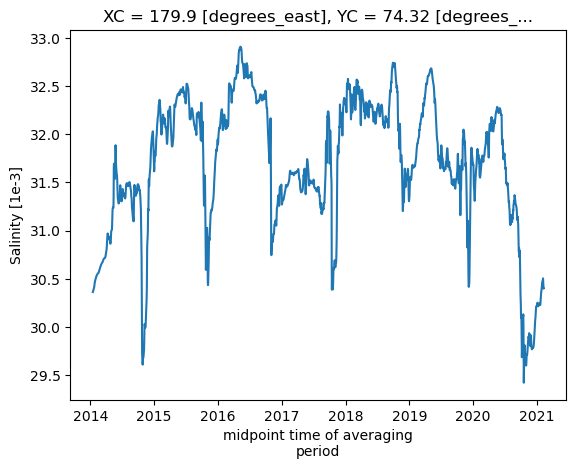

In [7]:
%%time
ds["SALT"].isel(i=600, j=600, k=10).plot()